In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib as mpl
from sklearn.linear_model import LinearRegression
import numba as nb
from numba import prange
from matplotlib import cm
import math
import time
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset
from matplotlib import pylab
from tqdm import tqdm
import os
import matplotlib.ticker as ticker
import numpy as np
import rasterio
import netCDF4 as nc
import os
import numba
from tqdm import tqdm
import random
from pyproj import Transformer
import xarray as xr
import csv
from matplotlib.patches import FancyArrowPatch
from ipywidgets import FloatSlider, interact
from matplotlib.widgets import Button, Slider
from ipywidgets import interact

# Classe

In [2]:
#@nb.njit(cache=True)
def _searchsorted(arr: np.ndarray, val: float) -> int:
    """Recherche binaire : retourne l'index i tel que arr[i] <= val < arr[i+1]."""
    lo, hi = 0, arr.shape[0] - 2          # on veut l'index gauche
    while lo < hi:
        mid = (lo + hi + 1) // 2
        if arr[mid] <= val:
            lo = mid
        else:
            hi = mid - 1
    return lo

#@nb.njit(cache=True, parallel=False)
def bilinear_interpolation(
    xs: np.ndarray,   # coordonnées x de la grille  (Nx,)  triées croissantes
    ys: np.ndarray,   # coordonnées y de la grille  (Ny,)  triées croissantes
    svf: np.ndarray,  # valeurs SVF                 (Ny, Nx)
    points: np.ndarray,  # points cibles             (N, 3)  colonnes x, y, z
) -> np.ndarray:
    """
    Interpolation bilinéaire de `svf` aux positions (x, y) de chaque point.
 
    Parameters
    ----------
    xs     : 1-D array de longueur Nx — axe x de la grille (croissant)
    ys     : 1-D array de longueur Ny — axe y de la grille (croissant)
    svf    : 2-D array (Ny, Nx)       — valeurs à interpoler
    points : 2-D array (N, 3)         — col 0 = x, col 1 = y, col 2 = z (ignoré)
 
    Returns
    -------
    result : 1-D array (N,) de valeurs SVF interpolées (NaN si hors grille)
    """
    N = points.shape[0]
    result = np.empty(N, dtype=np.float64)
 
    x_min, x_max = xs[0], xs[-1]
    y_min, y_max = ys[0], ys[-1]
 
    for k in range(N):
        px = points[k, 0]
        py = points[k, 1]
 
        # Hors domaine → NaN
        if px < x_min or px > x_max or py < y_min or py > y_max:
            result[k] = np.nan
            continue
 
        ix = _searchsorted(xs, px)
        iy = _searchsorted(ys, py)
        
        while (np.isnan(svf[iy,ix]) == True or svf[iy+1,ix+1] == True or
            svf[iy+1,ix] == True or svf[iy,ix+1] == True):
            
            ix = ix+1
            iy = iy+1
            
        x0, x1 = xs[ix], xs[ix + 1]
        y0, y1 = ys[iy], ys[iy + 1]
 
        # Poids de pondération
        tx = (px - x0) / (x1 - x0)
        ty = (py - y0) / (y1 - y0)
 
        # Coins de la cellule  svf[iy, ix] → ligne = y, colonne = x
        f00 = svf[iy,     ix    ]
        f10 = svf[iy,     ix + 1]
        f01 = svf[iy + 1, ix    ]
        f11 = svf[iy + 1, ix + 1]
 
        result[k] = (
            f00 * (1 - tx) * (1 - ty)
            + f10 *      tx  * (1 - ty)
            + f01 * (1 - tx) *      ty
            + f11 *      tx  *      ty
        )
 
    return result

def interpolate(
    ds: xr.Dataset,
    points: np.ndarray,
    var_name: str, #= "SVF",
    x_dim: str = "x",
    y_dim: str = "y",
) -> np.ndarray:
    """
    Interpole la variable `var_name` du dataset xarray aux positions (x, y)
    définies par un tableau de points 3D.
 
    Parameters
    ----------
    ds       : xr.Dataset contenant la variable et des coordonnées x/y régulières
    points   : np.ndarray de forme (N, 2) — colonnes [x, y]
    x_dim    : nom de la dimension x dans le dataset  (défaut : 'x')
    y_dim    : nom de la dimension y dans le dataset  (défaut : 'y')
    var_name : nom de la variable à interpoler        (défaut : 'SVF')
 
    Returns
    -------
    np.ndarray (N,) de valeurs interpolées (float64, NaN hors domaine)
    """
    # Extraction des tableaux NumPy (opération Python — hors numba)
    
    xs  = ds[x_dim].values.astype(np.float64)
    ys  = ds[y_dim].values.astype(np.float64)
    svf = ds[var_name].values.astype(np.float64)
 
    # Garantit que les axes sont croissants (xarray peut les stocker décroissants)
    if xs[-1] < xs[0]:
        xs  = xs[::-1].copy()
        svf = svf[:, ::-1].copy()
    if ys[-1] < ys[0]:
        ys  = ys[::-1].copy()
        svf = svf[::-1, :].copy()
 
    pts = np.ascontiguousarray(points, dtype=np.float64)
 
    return bilinear_interpolation(xs, ys, svf, pts)

In [3]:
params = {'legend.fontsize': 'x-large',
          #'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

@nb.njit()
def get_collisions(index, collision):
    collisions_index = collision[collision[:,0]==index][:,1:]
    return collisions_index

@nb.njit()
def get_pos_abs(coll):
    collision_finale = coll[coll[:,0] != 2][0,1:4]
    return collision_finale

@nb.njit()
def get_reflections(collisions):
    reflections = collisions[collisions[:,0] == 2][:,1:4]
    return reflections

#@numba.njit()
def get_dist(Pos_abs,pos_camera):
    return np.sqrt(np.sum((Pos_abs[:2]-pos_camera[:2])**2))

@nb.njit()
def get_Azimuth(Pos_abs,pos_camera):
    return math.atan2(Pos_abs[1]-pos_camera[1],Pos_abs[0]-pos_camera[0])

class MC_chemin:

    """
    Class pour un chemin. Donne son index, sa finallité (surf ou atm), son nombre de diffusions,
    de réflexion, son poids en triant dans le 2D array collisions
    """
    
    def __init__(self, data_path,pos_camera,W_tot):
        
        self.Index = data_path[0]
        self.Abs_surf = np.isclose(data_path[1],0.)
        self.Abs_atm = np.isclose(data_path[1],1.)
        self.Space = np.isclose(data_path[1],2.)

        self.wlen = data_path[7]
        self.Nbre_refl = data_path[2]
        # self.Nbre_diff = chemin[3] : pas de diffusion LW
        self.W = data_path[6] #/W_tot pour avoir la participation relative
        self.relative_weight = self.W/W_tot
        self.pos_camera = pos_camera

        #self.collision_self = get_collisions(self.Index, collisions)
        self.Pos_abs = np.array(data_path[3:6])
        #self.reflections = get_reflections(self.collision_self)
        self.Dist = get_dist(self.Pos_abs,pos_camera)
        self.Azimuth = get_Azimuth(self.Pos_abs,pos_camera)          
        
class MC_Set:
    
    """
    Classe sortant d'une simulation de MC. Statistique sur les chemins et figures
    """
    
    def __init__(self,data_path,pos_camera):
        
        if len(data_path) > 0 :
        
            # Caractéristique simu
            self.Nbre_photon = data_path.shape[0]
            self.pos_camera = pos_camera

            # Statistique de chemin   
            self.Nbre_reflexion = np.sum(data_path[:,2])
            self.Nbre_moyen_reflexion_exc = self.Nbre_reflexion/data_path[data_path[:,2] != 0].shape[0]
            self.Nbre_surf = data_path[(data_path[:,1] == 0.) & (data_path[:,2] == 0.)].shape[0]
            self.Nbre_atm = data_path[(data_path[:,1] == 1)  & (data_path[:,2] == 0)].shape[0]
            self.Nbre_reflect_surf = data_path[(data_path[:,1] == 0) & (data_path[:,2] != 0)].shape[0]
            self.Nbre_reflect_atm = data_path[(data_path[:,1] == 1)  & (data_path[:,2] != 0)].shape[0]            
            self.Nbre_space = data_path[data_path[:,1] == 2].shape[0]     

            # Poids par catégorie

            self.W_tot = np.sum(data_path[:,6])
            self.W_atm = np.sum(data_path[(data_path[:,1] == 1) & (data_path[:,2] == 0)][:,6])/self.W_tot

            self.W_reflechis_atm = np.sum(data_path[(data_path[:,2] != 0) & (data_path[:,1] == 1)][:,6])/self.W_tot
            self.W_reflechis_surf = np.sum(data_path[(data_path[:,2] != 0) & (data_path[:,1] == 0)][:,6])/self.W_tot

            if len(data_path[data_path[:,1] == 0]) > 0 :
                self.W_surf = np.sum(data_path[(data_path[:,1] == 0) & (data_path[:,2] == 0)][:,6])/self.W_tot
            else :
                self.W_surf = 0

            # Collection de classe chemin
            self.paths = [MC_chemin(data_path[i],pos_camera, self.W_tot) for i in range(data_path.shape[0])]        
    
        else :
            
            self.Nbre_photon = 50*15*15
            self.W_surf = 0
            self.W_tot = 0
            self.Nbre_surf = 0
            self.pos_camera = np.zeros(3)
            
    # Data methods ------------------------------------------------------------------------------------
        
    def class_selfs(self):
        print("La simu : \n",
              "\n pos_camera : x = %d\t" %self.pos_camera[0] \
              + "y = %d\t" %self.pos_camera[1] + "z = %d\t" %self.pos_camera[2],
             "\n Nbre_photon : %d" %self.Nbre_photon,
              
             "\n \n Stat sur les chemins : \n",
             "\n Nbre_moyen_reflexion_exc %.2f" %self.Nbre_moyen_reflexion_exc,
             "\n Nbre_reflexion : %d" %self.Nbre_reflexion,
             "\n Nbre_surf : %d" %self.Nbre_surf,
             "\n Nbre_atm : %d" %self.Nbre_atm,
             "\n Nbre_space : %d" %self.Nbre_space,
             "\n Nbre_reflect_surf : %d" %self.Nbre_reflect_surf,
             "\n Nbre_reflect_atm : %d" %self.Nbre_reflect_atm,
              
             "\n \n Poids par catégorie : \n",
             "\n W_tot : %f" %self.W_tot,
             "\n W_atm : %f" %self.W_atm,
             "\n W_surf : %f" %self.W_surf,
             "\n W_reflechis_atm : %f" %self.W_reflechis_atm,
             "\n W_reflechis_surf : %f" %self.W_reflechis_surf)
        
    def get_coord(self, coord, booli):
        
        if coord == 'x':
            indice = 0
        elif coord == 'y':
            indice = 1
        elif coord == 'z':
            indice = 2
            
        return [self.paths[i].Pos_abs[indice] for i in range(len(self.paths)) \
                if self.paths[i].Abs_surf == booli]
        
    def distance_to_plane(self,phi,Pos_abs,max_dist):
        
        n_plan = np.array([-np.sin(phi),np.cos(phi)])
        dist_ortho = abs(np.dot(n_plan,(Pos_abs[:2]-self.pos_camera[:2])))/np.sqrt(np.dot(n_plan,n_plan))
        
        if dist_ortho > max_dist :
            return False
        
        else :
            return True
        
    def projection_on_plane(self,phi,Pos_abs):
        
        t_plan = np.array([np.cos(phi), np.sin(phi)])
        
        return np.dot(t_plan,(Pos_abs[:2] - self.pos_camera[:2]))/np.sqrt(np.dot(t_plan,t_plan))
    
    
    def coord_proj_plane(self, phi, max_dist):
        
        a = len(self.paths)
            
        Surface = [np.array([self.projection_on_plane(phi,self.paths[i].Pos_abs),self.paths[i].Pos_abs[2],self.paths[i].W]) \
                   for i in range(a) if \
                   (self.distance_to_plane(phi,self.paths[i].Pos_abs,max_dist) == True and \
                    self.paths[i].Abs_surf == True)]
        Atm = [np.array([self.projection_on_plane(phi,self.paths[i].Pos_abs),self.paths[i].Pos_abs[2],self.paths[i].W]) for i in range(a) if \
                   (self.distance_to_plane(phi,self.paths[i].Pos_abs,max_dist) == True and \
                    self.paths[i].Abs_surf == False)]
    
        return Surface, Atm
    
    def z_profile(self, Surface):
        
        z = [self.paths[i].Pos_abs[2] for i in range(len(self.paths)) if self.paths[i].Abs_surf == Surface and \
            self.paths[i].Space == False]
        W = [self.paths[i].W for i in range(len(self.paths)) if self.paths[i].Abs_surf == Surface and \
            self.paths[i].Space == False]
        
        if len(z) >0 :
                
            paired = list(zip(z, W/self.W_tot))
            paired_sorted = sorted(paired, key=lambda x: x[0])
            z_sorted, var_sorted = zip(*paired_sorted)    
            
        else :
            z_sorted, var_sorted = [np.nan, np.nan]
        
        return z_sorted, var_sorted
    
    def dist_profile(self, Surface):
        
        Dist = [self.paths[i].Dist for i in range(len(self.paths)) if self.paths[i].Abs_surf == Surface and \
            self.paths[i].Space == False]
        W = [self.paths[i].W for i in range(len(self.paths)) if self.paths[i].Abs_surf == Surface and \
            self.paths[i].Space == False]
        
        if len(W) >0 :

            paired = list(zip(Dist, W/self.W_tot))
            paired_sorted = sorted(paired, key=lambda x: x[0])
            z_sorted, var_sorted = zip(*paired_sorted)    
        
        else :
            z_sorted, var_sorted = [np.nan, np.nan]
        
        
        return z_sorted, var_sorted
    
    def Z_radiance_tot(self,z_profile,T_profile):

        sigma = 5.67*(10**(-8))
        radiance_profile = sigma*(T_profile**4)
        
        diff_liste = abs(radiance_profile - (self.W_atm+self.W_reflechis_atm)*(self.W_tot/self.Nbre_photon))
        
        indice_z = diff_liste.argmin()
                    
        return z_profile[indice_z]
    
    def Matrice_cumuls(self,z_max,r_max,n_z,n_r, surface):
        
        Mat_cumul = np.zeros((n_z,n_r))
        
        zs = np.linspace(0,z_max,n_z)
        rs = np.linspace(0,r_max,n_r)
        
        Nbre_tot = self.Nbre_photon - self.Nbre_space
                
        for i in range(n_z):
            for j in range(n_r):
                                
                Mat_cumul[i,j] = len([self.paths[k].Dist for k in range(self.Nbre_photon) if \
                                        (self.paths[k].Abs_surf == surface) and (self.paths[k].Space == False) and \
                                           (self.paths[k].Dist < rs[j]) and \
                                           (self.paths[k].Pos_abs[2] - self.pos_camera[2] < zs[i])])/Nbre_tot
        
        return Mat_cumul,zs,rs
    
    def quartil_cumul_collision(self,type_,quantil):
        
        pathes = [self.paths[i] for i in range(len(self.paths)) if \
             self.paths[i].Abs_surf == True and self.paths[i].Space == False]   
        
        if type_ == "dist" :
                
            Dist = np.array([pathes[i].Dist for i in range(len(pathes))])
            res = np.percentile(Dist, quantil)
        
        elif type_ == "alt" :
            
            Alt = np.array([pathes[i].Pos_abs[2] for i in range(len(pathes))])
            res = np.percentile(Alt, quantil)         
        
        return res
    
    
    def quartil_cumul_flux(self,type_,quantil):
        
        pathes = [self.paths[i] for i in range(len(self.paths)) if \
             self.paths[i].Abs_surf == True and self.paths[i].Space == False]   
        
        if type_ == "dist" :
                
            Dist = np.array([pathes[i].Dist for i in range(len(pathes))])
            W = np.array([pathes[i].W/self.Nbre_photon for i in range(len(pathes))])
            
            paired = list(zip(Dist, W))
            paired_sorted = sorted(paired, key=lambda x: x[0])
            dist_sorted, W_sorted = zip(*paired_sorted)
            W_sorted_cum = np.cumsum(W_sorted)
            index_90 = np.argmax(W_sorted_cum > (quantil/100)*W_sorted_cum[-1])
            return dist_sorted[index_90]
        
        elif type_ == "alt" :
            
            
            Alt = np.array([pathes[i].Pos_abs[2] for i in range(len(pathes))])
            W = np.array([pathes[i].W/self.Nbre_photon for i in range(len(pathes))])
            
            paired = list(zip(Alt, W))
            paired_sorted = sorted(paired, key=lambda x: x[0])
            Alt_sorted, W_sorted = zip(*paired_sorted)
            W_sorted_cum = np.cumsum(W_sorted)
            index_90 = np.argmax(W_sorted_cum > (quantil/100)*W_sorted_cum[-1])
            return Alt_sorted[index_90]
               
    def Pos_surf(self,
                ds : xr.Dataset):
        
        sigma = 5.67e-8
        pathes = [self.paths[i] for i in range(len(self.paths)) if \
             self.paths[i].Abs_surf == True and self.paths[i].Space == False]
        
        Pos = np.array([pathes[i].Pos_abs[:2] for i in range(len(pathes))])
        Ts = interpolate(
                ds = ds,
                points = Pos,
                var_name ='ts',
                x_dim = "x",
                y_dim = "y",
                )
         
        return np.sum(sigma*Ts**4)/self.Nbre_photon
    
# Plot methods ------------------------------------------------------------------------------------
    
    def plot_atm_radiance_profile_4(self,ax,color,Surface, name):

        z = [self.paths[i].Pos_abs[2] - self.pos_camera[2] for i in range(len(self.paths)) if \
             self.paths[i].Abs_surf == Surface and self.paths[i].Space == False]
        
        z_sorted = sorted(z)
        
        Collisions = np.ones((1,len(z)))[0]
        
        Nbre_abs = self.Nbre_photon - self.Nbre_space
        ax.plot(np.cumsum(Collisions)/Nbre_abs,z_sorted,c = color, linestyle = 'solid', \
                 label = name)
    
    def plot_atm_radiance_profile_Planck(self,ax,color,Surface = False):
        
        pathes = [self.paths[i] for i in range(len(self.paths)) if \
             self.paths[i].Abs_surf == Surface and self.paths[i].Space == False]

        z = [pathes[i].Pos_abs[2] - self.pos_camera[2] for i in range(len(pathes))]
        
        norm = [np.sqrt(np.dot(pathes[i].Pos_abs - self.pos_camera,self.paths[i].Pos_abs - self.pos_camera)) for i in \
                 range(len(pathes))]
        
        ctheta = [np.dot(pathes[i].Pos_abs - self.pos_camera,np.array([0,0,1]))/norm[i] for i in \
                 range(len(pathes))]
        
        W = [ctheta[i]*pathes[i].W/np.pi for i in range(len(pathes))]

        ax.scatter(W,z,c = color)
    
    def plot_atm_radiance_profile_3(self,ax,color,Surface, name):

        z = [self.paths[i].Pos_abs[2] - self.pos_camera[2] for i in range(len(self.paths)) if \
             self.paths[i].Abs_surf == Surface and self.paths[i].Space == False]
        W = [self.paths[i].W for i in range(len(self.paths)) if self.paths[i].Abs_surf == Surface and \
            self.paths[i].Space == False]
        
        paired = list(zip(z, W/self.W_tot))
        paired_sorted = sorted(paired, key=lambda x: x[0])
        z_sorted, var_sorted = zip(*paired_sorted)

        ax.plot(np.cumsum(var_sorted),z_sorted,c = color, linestyle = 'solid', \
                 label = name)
                             
    def dist_weight_4(self, ax, Surface, color, name):
                
        Dist = [self.paths[i].Dist for i in range(len(self.paths)) if self.paths[i].Abs_surf == Surface and \
            self.paths[i].Space == False]
        Dist_sorted = sorted(Dist)
    
        Collisions = np.ones((1,len(Dist)))[0]                  

        Nbre_abs = self.Nbre_photon - self.Nbre_space
        ax.plot(Dist_sorted,np.cumsum(Collisions)/Nbre_abs, c = color, linestyle = 'solid',\
                label = name)
        
    def dist_weight_3(self, ax, Surface, color, name):
        
                
        Dist = [self.paths[i].Dist for i in range(len(self.paths)) if self.paths[i].Abs_surf == Surface  and \
            self.paths[i].Space == False]
        
        W = [self.paths[i].W for i in range(len(self.paths)) if self.paths[i].Abs_surf == Surface and \
            self.paths[i].Space == False]                
    
        paired = list(zip(Dist, W))
        paired_sorted = sorted(paired, key=lambda x: x[0])
        Dist_sorted, W = zip(*paired_sorted)    

        ax.plot(Dist_sorted,np.cumsum(W)/self.W_tot, c = color, linestyle = 'solid',\
                label = name)

    def plot_atm_radiance_profile_2(self,ax,color,Surface, name,vmin,vmax):
        
        z = [self.paths[i].Pos_abs[2] - self.pos_camera[2] for i in range(len(self.paths)) if self.paths[i].Abs_surf == Surface and \
            self.paths[i].Space == False]
        W = [self.paths[i].W for i in range(len(self.paths)) if self.paths[i].Abs_surf == Surface and \
            self.paths[i].Space == False]
        
        cax = ax.scatter(W,z, s = 0.5,c = W, vmin = vmin, vmax= vmax, cmap = 'Reds', \
                         marker = 'o', label = 'Chemins ' + name)
        
        ax2 = ax.twiny()            
        paired = list(zip(z, W/self.W_tot))
        paired_sorted = sorted(paired, key=lambda x: x[0])
        z_sorted, var_sorted = zip(*paired_sorted)

        ax2.plot(np.cumsum(var_sorted),z_sorted,c = color, linestyle = 'solid', \
                 label = 'Cumulative relative flux ' + name)
        Nbre_photon_abs = self.Nbre_photon - self.Nbre_space
        ax2.plot(np.cumsum(np.ones((1,len(var_sorted))))/Nbre_photon_abs,z_sorted,c = color, \
                   label = 'Cumulative count ' + name, linestyle = 'dashed')

        ax2.spines[['left','right', 'top', 'bottom']].set_visible(False)
        
        ax.set_xlabel('Thermal flux ($W/m^2$)')
        ax.set_ylabel('Altitude of absorption (m)')
        ax.spines[['left','right', 'top', 'bottom']].set_visible(False)
        
        ax2.set_xlim((0,1))
        
        ax2.legend()
        #ax.legend()
       
    def temperature_profile(self):
    
        directory = "/home/barroisl/edstar/Simus/"
        fname = "ecrad_opt_prop.txt"
        data_path = np.loadtxt(directory+fname, dtype = np.float32,skiprows = 172)

        Temperatures = data_path[:165]-100
        Altitudes = data_path[165:330]

        return Temperatures, Altitudes
    

    def plot_atm_profile_2_integer_spectral(self,ax,color,vmin,vmax):
        
        directory = "/home/barroisl/edstar/Simus/"
        fname = "ecrad_opt_prop.txt"
        data_path = np.loadtxt(directory+fname, dtype = np.float32,skiprows = 172)

        Temperatures = data_path[:165]
        Altitudes = data_path[165:330]
        
        Temperatures = Temperatures[Altitudes > self.pos_camera[2]]
        Altitudes = Altitudes[Altitudes > self.pos_camera[2]] - self.pos_camera[2]

        sigma = 5.67*10**(-8)
        plt.plot(sigma*Temperatures**4,Altitudes,'r')
        
        cax = ax.scatter(sigma*Temperatures**4,Altitudes, s = 0.5,c = 'blue', \
                         vmin = vmin, vmax= vmax, \
                         marker = 'o', label = 'SB')       
        
        """
        Temperatures, Altitudes = self.temperature_profile()
        
        Paths_liste = [self.paths[i] for i in range(len(self.paths)) if \
                      self.paths[i].Abs_atm == True and self.paths[i].Space == False]
        
        z = np.array([Paths_liste[i].Pos_abs[2] for i in range(len(Paths_liste))])
        
        sigma = 5.67*10**(-8)
        W = sigma*np.interp(z, Altitudes, Temperatures)**4
        
        cax = ax.scatter(W,z, s = 0.5,c = W, vmin = vmin, vmax= vmax, cmap = 'Blues', \
                         marker = 'o', label = 'SB')       
        """
        
    def plot_atm_radiance_profile_2_clouds(self,ax,color,z_bottom_clouds,z_top_clouds,name,vmin,vmax):
        
        Temperatures, Altitudes = self.temperature_profile()
        
        Paths_liste = [self.paths[i] for i in range(len(self.paths)) if \
                      self.paths[i].Abs_atm == True and self.paths[i].Space == False]
           
        if self.pos_camera[2] < z_bottom_clouds :
            z = np.array([Paths_liste[i].Pos_abs[2] if Paths_liste[i].Pos_abs[2] < z_bottom_clouds else z_bottom_clouds \
                 for i in range(len(Paths_liste))])
            
        elif self.pos_camera[2] > z_bottom_clouds and self.pos_camera[2] < z_top_clouds:
            z = np.array([Paths_liste[i].pos_camera[2] for i in range(len(Paths_liste))])  
            
        else :
            z = np.array([Paths_liste[i].Pos_abs[2] for i in range(len(Paths_liste))])
        
        sigma = 5.67*10**(-8)
        W = sigma*np.interp(z, Altitudes, Temperatures)**4
        
        cax = ax.scatter(W,z, s = 0.5,c = W, vmin = vmin, vmax= vmax, cmap = 'Reds', \
                         marker = 'o', label = 'Chemins ' + name)
        
        ax2 = ax.twiny()            
        paired = list(zip(z, W/self.W_tot))
        paired_sorted = sorted(paired, key=lambda x: x[0])
        z_sorted, var_sorted = zip(*paired_sorted)

        ax2.plot(np.cumsum(var_sorted),z_sorted,c = color, linestyle = 'solid', \
                 label = 'Cumulative relative flux ' + name)
        Nbre_photon_abs = self.Nbre_photon - self.Nbre_space
        ax2.plot(np.cumsum(np.ones((1,len(var_sorted))))/Nbre_photon_abs,z_sorted,c = color, \
                   label = 'Cumulative count ' + name, linestyle = 'dashed')

        ax2.spines[['left','right', 'top', 'bottom']].set_visible(False)
        
        ax.set_xlabel('Thermal flux ($W/m^2$)')
        ax.set_ylabel('Altitude of absorption (m)')
        ax.spines[['left','right', 'top', 'bottom']].set_visible(False)
        
        ax2.set_xlim((0,1.5))
        
        ax2.legend()
        #ax.legend()
            
    def plot_atm_radiance_profile(self,axs,Variable, save_title):
        
        sigma = 5.67*10**(-8)
        
        # Atm absorbed
        
        z = [self.paths[i].Pos_abs[2] for i in range(len(self.paths)) if self.paths[i].Abs_surf == False]
        if Variable == 'W' :
            var = [self.paths[i].W for i in range(len(self.paths)) if self.paths[i].Abs_surf == False]
            xlabel = 'Weight ($W/m^2$)'
                        
            ax2 = axs[0].twiny()            
            paired = list(zip(z, var/self.W_tot))
            paired_sorted = sorted(paired, key=lambda x: x[0])
            z_sorted, var_sorted = zip(*paired_sorted)

            ax2.plot(np.cumsum(var_sorted),z_sorted,c = 'r')
            
            ax2.plot(np.cumsum(np.ones((1,len(var))))/len(var),z_sorted,c = 'b', \
                       label = 'Cumulative count')
            
            ax2.spines[['left','right', 'top', 'bottom']].set_visible(False)
            
        elif Variable == 'T' :
            var = [(self.paths[i].W/sigma)**(1/4) for i in range(len(self.paths)) if self.paths[i].Abs_surf == False]
            xlabel = 'Température de radiance'
            
        cax = axs[0].scatter(var,z, s = 0.5,c = 'k', marker = 'o')
        
        axs[0].set_title('Absorbed by Atmosphere : %.2f ($W/m^2$)' %(self.W_atm*self.W_tot))
        
        # Surface absorbed
        
        if len([self.paths[i].Dist for i in range(len(self.paths)) \
                if self.paths[i].Abs_surf == True]) != 0 :
        
            z = [self.paths[i].Pos_abs[2] for i in range(len(self.paths)) if self.paths[i].Abs_surf == True]
            if Variable == 'W' :
                var = [self.paths[i].W for i in range(len(self.paths)) if self.paths[i].Abs_surf == True]
                xlabel = 'Weight ($W/m^2$)'

                ax2 = axs[1].twiny()            
                paired = list(zip(z, var/self.W_tot))
                paired_sorted = sorted(paired, key=lambda x: x[0])
                z_sorted, var_sorted = zip(*paired_sorted)

                ax2.plot(np.cumsum(var_sorted),z_sorted, c = 'r', \
                            label = 'Cumulative relative weight')

                ax2.plot(np.cumsum(np.ones((1,len(var))))/len(var),z_sorted,c = 'b', \
                           label = 'Cumulative count')

                ax2.spines[['left','right', 'top', 'bottom']].set_visible(False)

                ax2.legend()

            elif Variable == 'T' :
                var = [(self.paths[i].W/sigma)**(1/4) for i in range(len(self.paths)) if self.paths[i].Abs_surf == True]
                xlabel = 'Température de radiance'
            
        cax = axs[1].scatter(var,z, s = 0.5,c = 'k', marker = 'o', label = Variable)  
        
        axs[1].set_title('Absorbed by Surface : %.2f ($W/m^2$)' %(self.W_surf*self.W_tot))
        
        for ax in axs :
            ax.set_xlabel(xlabel)
            ax.set_ylabel('Altitude of absorption (m)')
            ax.spines[['left','right', 'top', 'bottom']].set_visible(False)

        plt.savefig(save_title)
        
    def histogramme(self,ax,variable) :
        
        if variable == 'Dist':
            var = [self.paths[i].Dist for i in range(len(self.paths))]
        elif variable == 'z':
            var = [self.paths[i].Pos_abs[2] for i in range(len(self.paths))]
        elif variable == 'W':
            var = [self.paths[i].W for i in range(len(self.paths))]
            
        hist = ax.hist(variable, bins = np.arange(100)*100, histtype = 'step')

        ax.set_ylabel('Count')
        ax.set_xlabel('Distance to camera (m)')
        ax.spines[['left','right', 'top', 'bottom']].set_visible(False)
        
    def threeD_scat(self, fig):
        
        ax = fig.add_subplot(projection='3d')
        
        markers = ['o','+']
        boolis = [True, False]
        
        for j in range(2):
            
            x = self.get_coord('x', boolis[j])
            y = self.get_coord('y', boolis[j])
            z = self.get_coord('z', boolis[j])
            
            W = [self.paths[i].W for i in range(len(self.paths)) \
                if self.paths[i].Abs_surf == boolis[j]]

            cax = ax.scatter(x, y, z, c = W, marker = markers[j], cmap = 'viridis', vmin = 0, vmax = 30)
            
        fig.colorbar(cax, label = 'Relative importance in raddiance')

        ax.set_xlabel('x (m)')
        ax.set_ylabel('y (m)')
        ax.set_zlabel('z (m)')
        ax.grid(False)
        
    def twoD_scat(self, ax, fig,save_title):
        
        markers = ['o','+']
        boolis = [True, False]
        
        for j in range(2):
        
            x = self.get_coord('x', boolis[j])
            y = self.get_coord('y', boolis[j])

            W = [self.paths[i].W for i in range(len(self.paths)) \
                if self.paths[i].Abs_surf == boolis[j]]
                        
            cax = ax.scatter(x, y, marker = markers[j], c = W, cmap = 'viridis')
            
        fig.colorbar(cax, label = 'Radiance ($W/m^2$)')

        ax.set_xlabel('x (m)')
        ax.set_ylabel('y (m)')
        ax.spines[['left','right', 'top', 'bottom']].set_visible(False) 
        
        plt.savefig(save_title)
        
    def dist_weight_2(self, ax, Surface, color, name):
        
        ax2 = ax.twinx()
        
        Dist = [self.paths[i].Dist for i in range(len(self.paths)) \
            if self.paths[i].Abs_surf == Surface and self.paths[i].Space == False]

        W = [self.paths[i].W for i in range(len(self.paths)) \
            if self.paths[i].Abs_surf == Surface and self.paths[i].Space == False]

        cax = ax.plot(Dist, W, c = color, markersize = 1, marker = 'o', label = "Chemin "+name,linestyle='')

        paired = list(zip(Dist, W))
        paired_sorted = sorted(paired, key=lambda x: x[0])
        Dist_sorted, W = zip(*paired_sorted)    
        
        ax2.plot(Dist_sorted,np.cumsum(W)/self.W_tot, c = color, linestyle = 'solid',\
                label = "Cumulative relative weight " + name)
        
        Nbre_photon_abs = self.Nbre_photon - self.Nbre_space
        ax2.plot(Dist_sorted, np.cumsum(np.ones((1,len(W))))/Nbre_photon_abs,c = color, \
                   label = 'Cumulative count ' + name, linestyle = 'dashed')
        
        ax2.spines[['left','right', 'top', 'bottom']].set_visible(False)
        
        ax.set_ylabel('Weight ($W/m^2$)')
        ax.set_xlabel('Distance of absorption (m)')
        ax.spines[['left','right', 'top', 'bottom']].set_visible(False)
        
        ax2.set_ylim((0,1))
        
        ax2.legend()
        
    def dist_weight(self, axs, save_title):
        
        ax2 = axs[0].twinx()
        ax3 = axs[1].twinx()
        
        markers = ['o','+']
        boolis = [True, False]
        colors = ['green','blue']
        labels = ['Surface', 'Atm']
                
        for j in range(2):
            
            if len([self.paths[i].Dist for i in range(len(self.paths)) \
                if self.paths[i].Abs_surf == boolis[j]]) == 0 :
                
                j = 1
        
            Dist = [self.paths[i].Dist for i in range(len(self.paths)) \
                if self.paths[i].Abs_surf == boolis[j]]

            W = [self.paths[i].W for i in range(len(self.paths)) \
                if self.paths[i].Abs_surf == boolis[j]]
            
            Azi = [self.paths[i].Azimuth for i in range(len(self.paths)) \
                if self.paths[i].Abs_surf == boolis[j]]
            
                        
            cax = axs[0].scatter(Dist, W, marker = markers[j], c = 'k')
            
            paired = list(zip(Dist, W))
            paired_sorted = sorted(paired, key=lambda x: x[0])
            Dist_sorted, W = zip(*paired_sorted)
            
            
            ax2.plot(Dist_sorted,np.cumsum(W)/np.cumsum(W)[-1], c = colors[j], \
                        label = labels[j])
            
            if j == 0 :
                cax = axs[1].scatter(Dist, W, marker = markers[j], c = 'k')

                ax3.plot(Dist_sorted,np.cumsum(W)/np.cumsum(W)[-1], c = colors[j], \
                        label = labels[j])
                            
        W = [self.paths[i].W/self.W_tot for i in range(len(self.paths))]
        Dist = [self.paths[i].Dist for i in range(len(self.paths))]
        
        paired = list(zip(Dist, W))
        paired_sorted = sorted(paired, key=lambda x: x[0])
        Dist_sorted, W = zip(*paired_sorted)

        ax2.plot(Dist_sorted,np.cumsum(W), c = 'r', \
                    label = 'Cumulative weight total')

        ax2.spines[['left','right', 'top', 'bottom']].set_visible(False)
        ax3.spines[['left','right', 'top', 'bottom']].set_visible(False)

        ax2.legend() 
        
        for i in range(2):
            ax = axs[i]
            ax.set_xlabel('Distance from camera (m)')
            ax.set_ylabel('Weight')
            ax.spines[['left','right', 'top', 'bottom']].set_visible(False) 
        
        plt.savefig(save_title)        
                 
    def plotting_pcolor_cumul(self, ax, Mat_cumul,zs,rs, norm, cmap):
    
        cax = ax.pcolormesh(Mat_cumul, cmap = cmap, norm = norm)
    
    def figure_utile(self,type_name):

        fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6), layout = 'constrained')

        save_title = '/home/barroisl/edstar/Simus/Output/Dist_W_15_15_10_'+type_name+'.png'

        set_c.dist_weight(axs, save_title)

        plt.close()

        fig, axs = plt.subplots(nrows = 1, ncols = 2,figsize = (12,6), layout = 'constrained')

        save_title = '/home/barroisl/edstar/Simus/Output/W_15_15_10_'+type_name+'.png'

        set_c.plot_atm_radiance_profile(axs,'W',save_title)

        plt.close()

        fig,ax = plt.subplots(figsize = (6,6), layout = 'constrained')

        save_title = '/home/barroisl/edstar/Simus/Output/W_xy_15_15_10_'+type_name+'.png'

        set_c.twoD_scat(ax, fig, save_title)

        plt.close()
    
    def plotting_rose(self,ax,grid_fact,surface,cmap,vmin,vmax,add_colorbar):
        
        # Structure of the diagramme
        
        compass_angles = np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315])  # N, NE, E, SE, S, SW, W, NW
        compass_labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
        ax.set_xticks(compass_angles)         
        ax.set_xticklabels(compass_labels)    

        ax.set_theta_zero_location('N')       
        ax.set_theta_direction(-1)            
        ax.set_rticks([5])                     

        for R in range(1,5): 
            plotting_circle_labeled(R*grid_fact,ax)
            
        
        #Collision points
        
        bounds = np.arange(vmin, vmax, (vmax-vmin)*0.1)
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256)
        
        path_considered = [self.paths[i] for i in range(len(self.paths)) if \
                           self.paths[i].Abs_surf == surface and self.paths[i].Space == False]
        
        Dist = [path_considered[i].Pos_abs[2]-self.pos_camera[2] for i in range(len(path_considered))]
        W = [path_considered[i].W for i in range(len(path_considered))]
        Azi = [path_considered[i].Azimuth for i in range(len(path_considered))]
        
        cax = ax.scatter(Azi,Dist,c = W,cmap = cmap, norm = norm)
        
        if add_colorbar == True :
            
            cbar = plt.colorbar(cax, ax=ax,location='right', orientation='vertical', cmap = cmap, norm = norm)
            cbar.set_label('Weight $W.m^{-2}$')
            
    def plotting_collision_map(self,ax,surface,cmap,vmin,vmax,add_colorbar):
        
        #Collision points
        
        bounds = np.arange(vmin, vmax, (vmax-vmin)*0.1)
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256)
        
        path_considered = [self.paths[i] for i in range(len(self.paths)) if \
                           self.paths[i].Abs_surf == surface and self.paths[i].Space == False]
        
        x = [path_considered[i].Pos_abs[0] for i in range(len(path_considered))]
        y = [path_considered[i].Pos_abs[1] for i in range(len(path_considered))]
        W = [path_considered[i].W for i in range(len(path_considered))]
        
        cax = ax.scatter(x,y,c = W,s=1,cmap = cmap, norm = norm)
        
        if add_colorbar == True :
            
            cbar = plt.colorbar(cax, ax=ax,location='right', orientation='vertical', extend = 'max',cmap = cmap, norm = norm)
            cbar.set_label('Thermal flux $W.m^{-2}$')
            
    def plotting_collision_map_2(self,ax,color):    
        
        path_considered = [self.paths[i] for i in range(len(self.paths)) if \
                           self.paths[i].Abs_surf == True and self.paths[i].Space == False]
        
        x = [path_considered[i].Pos_abs[0] for i in range(len(path_considered))]
        y = [path_considered[i].Pos_abs[1] for i in range(len(path_considered))]
        W = [path_considered[i].W for i in range(len(path_considered))]
        
        cax = ax.scatter(x,y,c = color,s=1)

In [4]:
def sensibility_z(
            dir_data : str,
            )->np.ndarray:
    
    taux_surf = np.zeros((16,12))
    flux_surf = np.zeros((16,12))
    alt_dz = np.arange(16)
    Pos_camera = np.zeros((12,3))
    
    list_dz = os.listdir(dir_data) # les différences d'altitudes, 11 pour [-10,6,3,2,1,0...]
    for j,dz in enumerate(list_dz) :
        list_cam = os.listdir(dir_data+dz+"/") # Les numéro de dossier, 12 pour chartreuse_3
        print(dz)
        for i,dossier in enumerate(list_cam):
            data = np.loadtxt(dir_data + dz + '/' + dossier + '/'+ dossier +'_50_15_15.txt')
            pos_camera = np.loadtxt(dir_data + dz + '/' + dossier + '/'+ dossier +'_camera_tgt.txt')[:3]
            mc_set = MC_Set(data, pos_camera)
            
            #print(mc_set.Nbre_surf)
            if j == 0 :
                Pos_camera[i] = mc_set.pos_camera
            
            taux_surf[j,i] = 100*mc_set.Nbre_surf/mc_set.Nbre_photon
            flux_surf[j,i] = mc_set.W_surf*mc_set.W_tot/mc_set.Nbre_photon
        alt_dz[j]= dz
    
    return Pos_camera,alt_dz,taux_surf,flux_surf

# Sensibilité position verticale de la caméra

In [136]:
dir_data = "/home/barroisl/Transect_MC_auto/Data/chartreuse_z_sensibility/"
warnings.filterwarnings('ignore')
Pos_camera,alt_dz,taux_surf,flux_surf = sensibility_z(
            dir_data = dir_data)

-10


/tmp/ipykernel_22693/2581780110.py:15: UserWarning: loadtxt: input contained no data: "/home/barroisl/Transect_MC_auto/Data/chartreuse_z_sensibility/-10/2/2_50_15_15.txt"
  data = np.loadtxt(dir_data + dz + '/' + dossier + '/'+ dossier +'_50_15_15.txt')
/tmp/ipykernel_22693/2581780110.py:15: UserWarning: loadtxt: input contained no data: "/home/barroisl/Transect_MC_auto/Data/chartreuse_z_sensibility/-10/1/1_50_15_15.txt"
  data = np.loadtxt(dir_data + dz + '/' + dossier + '/'+ dossier +'_50_15_15.txt')
/tmp/ipykernel_22693/2581780110.py:15: UserWarning: loadtxt: input contained no data: "/home/barroisl/Transect_MC_auto/Data/chartreuse_z_sensibility/-10/3/3_50_15_15.txt"
  data = np.loadtxt(dir_data + dz + '/' + dossier + '/'+ dossier +'_50_15_15.txt')
/tmp/ipykernel_22693/2581780110.py:15: UserWarning: loadtxt: input contained no data: "/home/barroisl/Transect_MC_auto/Data/chartreuse_z_sensibility/-10/4/4_50_15_15.txt"
  data = np.loadtxt(dir_data + dz + '/' + dossier + '/'+ dossier +'

-6


/tmp/ipykernel_22693/2581780110.py:15: UserWarning: loadtxt: input contained no data: "/home/barroisl/Transect_MC_auto/Data/chartreuse_z_sensibility/-6/12/12_50_15_15.txt"
  data = np.loadtxt(dir_data + dz + '/' + dossier + '/'+ dossier +'_50_15_15.txt')
/tmp/ipykernel_22693/2581780110.py:15: UserWarning: loadtxt: input contained no data: "/home/barroisl/Transect_MC_auto/Data/chartreuse_z_sensibility/-3/1/1_50_15_15.txt"
  data = np.loadtxt(dir_data + dz + '/' + dossier + '/'+ dossier +'_50_15_15.txt')
/tmp/ipykernel_22693/2581780110.py:15: UserWarning: loadtxt: input contained no data: "/home/barroisl/Transect_MC_auto/Data/chartreuse_z_sensibility/-3/2/2_50_15_15.txt"
  data = np.loadtxt(dir_data + dz + '/' + dossier + '/'+ dossier +'_50_15_15.txt')
/tmp/ipykernel_22693/2581780110.py:15: UserWarning: loadtxt: input contained no data: "/home/barroisl/Transect_MC_auto/Data/chartreuse_z_sensibility/-3/3/3_50_15_15.txt"
  data = np.loadtxt(dir_data + dz + '/' + dossier + '/'+ dossier +'_5

-3


...

1
2
3
6
10
100
-50


/tmp/ipykernel_22693/2581780110.py:15: UserWarning: loadtxt: input contained no data: "/home/barroisl/Transect_MC_auto/Data/chartreuse_z_sensibility/-50/1/1_50_15_15.txt"
  data = np.loadtxt(dir_data + dz + '/' + dossier + '/'+ dossier +'_50_15_15.txt')
/tmp/ipykernel_22693/2581780110.py:15: UserWarning: loadtxt: input contained no data: "/home/barroisl/Transect_MC_auto/Data/chartreuse_z_sensibility/-50/2/2_50_15_15.txt"
  data = np.loadtxt(dir_data + dz + '/' + dossier + '/'+ dossier +'_50_15_15.txt')
/tmp/ipykernel_22693/2581780110.py:15: UserWarning: loadtxt: input contained no data: "/home/barroisl/Transect_MC_auto/Data/chartreuse_z_sensibility/-50/3/3_50_15_15.txt"
  data = np.loadtxt(dir_data + dz + '/' + dossier + '/'+ dossier +'_50_15_15.txt')
/tmp/ipykernel_22693/2581780110.py:15: UserWarning: loadtxt: input contained no data: "/home/barroisl/Transect_MC_auto/Data/chartreuse_z_sensibility/-50/4/4_50_15_15.txt"
  data = np.loadtxt(dir_data + dz + '/' + dossier + '/'+ dossier +'

-20


/tmp/ipykernel_22693/2581780110.py:15: UserWarning: loadtxt: input contained no data: "/home/barroisl/Transect_MC_auto/Data/chartreuse_z_sensibility/-20/12/12_50_15_15.txt"
  data = np.loadtxt(dir_data + dz + '/' + dossier + '/'+ dossier +'_50_15_15.txt')


20
50


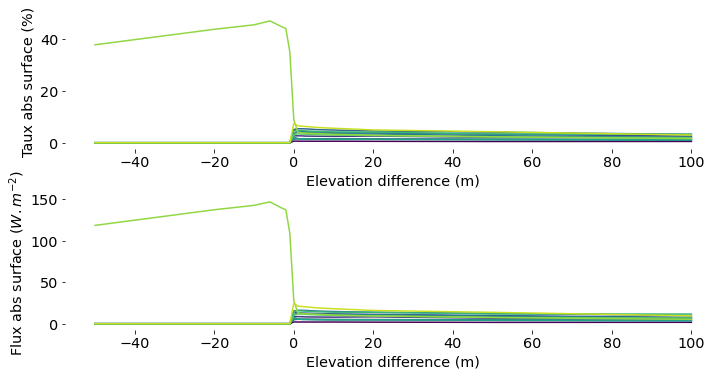

In [261]:
cmap = cm.viridis

fig,axs = plt.subplots(nrows= 2, ncols = 1,figsize = (10,5), layout = 'constrained')

a,b = taux_surf.shape

for j in range(b):
    
    color = cmap(j/b)
    
    paired = list(zip(alt_dz, taux_surf[:,j]))
    paired_sorted = sorted(paired, key=lambda x: x[0])
    alt_dz_sorted, taux_surf_sorted = zip(*paired_sorted)
    
    axs[0].plot(alt_dz_sorted,taux_surf_sorted,color = color)
    
    paired = list(zip(alt_dz, flux_surf[:,j]))
    paired_sorted = sorted(paired, key=lambda x: x[0])
    alt_dz_sorted, flux_surf_sorted = zip(*paired_sorted)

    axs[1].plot(alt_dz_sorted,flux_surf_sorted,color = color)
    
axs[0].spines[['left','right', 'top', 'bottom']].set_visible(False)
axs[0].set_ylabel('Taux abs surface (%)')
axs[0].set_xlabel("Elevation difference (m)")

axs[1].spines[['left','right', 'top', 'bottom']].set_visible(False)
axs[1].set_ylabel('Flux abs surface ($W.m^{-2}$)')
axs[1].set_xlabel("Elevation difference (m)")

#ax.set_xlim(0,10)
#ax.set_ylim(-1,15)

dire = "/home/barroisl/Transect_MC_auto/"
plt.savefig(dire+"Output/chartreuse_z_sensibility/comp_taux_surf.jpg")

In [241]:
# Un dictionnaire pour prendre en compte les collisions

def d_abs_surface(dir_data:str):
    
    d_abs = {}
    d_pos_cam = {}
    taux = np.zeros((12,))
    flux = {}
    
    list_dz = os.listdir(dir_data) # les différences d'altitudes, 11 pour [-10,6,3,2,1,0...]
    
    paired = list(zip([int(s) for s in list_dz], list_dz))
    paired_sorted = sorted(paired, key=lambda x: x[0])
    list_dz, list_dz_sorted = zip(*paired_sorted)
    
    taux = np.zeros((12,len(list_dz)))
    flux = np.zeros((12,len(list_dz)))
    
    for j,dz in enumerate(list_dz_sorted) :
        list_cam = os.listdir(dir_data+dz+"/") # Les numéro de dossier, 12 pour chartreuse_3
        print(dz)
        for i,dossier in enumerate(list_cam):
            data = np.loadtxt(dir_data + dz + '/' + dossier + '/'+ dossier +'_50_15_15.txt')
            pos_camera = np.loadtxt(dir_data + dz + '/' + dossier + '/'+ dossier +'_camera_tgt.txt')[:3]
            mc_set = MC_Set(data, pos_camera)
            
            if mc_set.W_surf > 0 :
            
                pathes = [mc_set.paths[i] for i in range(len(mc_set.paths)) if \
                    mc_set.paths[i].Abs_surf == True and mc_set.paths[i].Space == False]

                d_abs[f"{int(dz)}_{int(i)}"] = np.array([path.Pos_abs for path in pathes])
                d_pos_cam[f"{int(i)}"] = np.array([mc_set.pos_camera])
                
                taux[i,j] = mc_set.Nbre_surf/mc_set.Nbre_photon
                flux[i,j] = mc_set.W_surf*mc_set.W_tot/mc_set.Nbre_photon
            
            else :
                
                d_abs[f"{int(dz)}_{int(i)}"] = np.array([])
            
    return d_pos_cam,d_abs,taux,flux

In [242]:
import warnings
warnings.filterwarnings('ignore')

In [243]:
dir_data = "/home/barroisl/Transect_MC_auto/Data/chartreuse_z_sensibility/"

d_pos_cam,d_abs,taux,flux = d_abs_surface(dir_data=dir_data)

np.save("/home/barroisl/Transect_MC_auto/Data/dico_sensibilite/d_abs.npy", d_abs)
np.save("/home/barroisl/Transect_MC_auto/Data/dico_sensibilite/d_pos_cam.npy", d_pos_cam)
np.save("/home/barroisl/Transect_MC_auto/Data/dico_sensibilite/taux.npy", taux)
np.save("/home/barroisl/Transect_MC_auto/Data/dico_sensibilite/flux_cam.npy", flux)

-50
-20
-10
-6
-3
-2
-1
0
1
2
3
6
10
20
50
100


In [3]:
def plot_pos_abs_func_ij(Num_cam,dz):
    
    dz_closest = min(d_abs.item().keys(), key=lambda k: abs(int(k.split('_')[0]) - dz))
    dz_closest = dz_closest.split('_')[0]
    data = d_abs.item().get(f"{int(dz_closest)}_{int(Num_cam)}")
    pos_camera = d_pos_cam.item().get(f'{int(Num_cam)}')[0]
    
    #ds_topo
    ds_topo = xr.open_dataset("/home/barroisl/Transect_MC_auto/topographie/topo_params_250m.nc")
        
    fig, ax = plt.subplots(figsize = (5,5),\
                            layout = 'constrained')
    plot_pos_abs(
        fig = fig,
        ax = ax,
        ds_topo = ds_topo,
        data = data,
        pos_camera = pos_camera,
        xlim = (234000,258000),
        ylim = (5020000,5038000)
        )
    ax.set_title(f"Caméra n°{int(Num_cam)} pour un dz = {int(dz_closest)}")
    plt.show()
    
def plot_pos_abs(
    fig,
    ax,
    ds_topo : xr.Dataset,
    data : np.ndarray,
    pos_camera : np.ndarray,
    xlim,
    ylim):
    
    #Plotting topo contour
    ds_topo.zs.plot.contourf(ax = ax, add_colorbar = False, cmap = 'terrain', \
                                   levels = np.arange(200,1800,100), alpha = 0.5)
    
    #Plotting htrdr diagnostics
    if len(data) > 0 :
        cax = ax.scatter(data[:,0],data[:,1],color ='k', s=5)
    
    #Fancy camera position
    ax.scatter(pos_camera[0],pos_camera[1],color = 'dodgerblue', marker = '*')

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')

In [4]:
d_abs = np.load("/home/barroisl/Transect_MC_auto/Data/dico_sensibilite/d_abs.npy", allow_pickle = True)
d_pos_cam = np.load("/home/barroisl/Transect_MC_auto/Data/dico_sensibilite/d_pos_cam.npy", allow_pickle = True)
taux = np.load("/home/barroisl/Transect_MC_auto/Data/dico_sensibilite/taux.npy", allow_pickle = True)
flux = np.load("/home/barroisl/Transect_MC_auto/Data/dico_sensibilite/flux_cam.npy", allow_pickle = True)

Num_cam = FloatSlider(min=0, max=11, step=1, value=0.0,
                     description='Numéro caméra', continuous_update=False)
dz = FloatSlider(min=-50, max=50, step=1, value=0.0,
                     description='$\Delta z$', continuous_update=False)

interact(plot_pos_abs_func_ij,Num_cam=Num_cam,dz=dz)

<function __main__.plot_pos_abs_func_ij(Num_cam, dz)>

(5025000.0, 5030000.0)

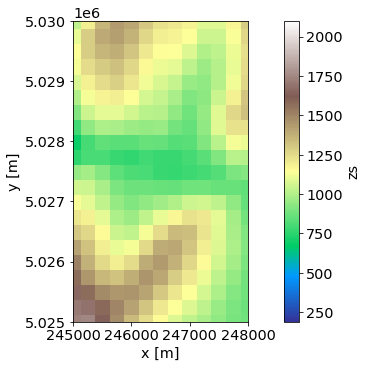

In [9]:
fig, ax = plt.subplots(figsize = (5,5),\
                            layout = 'constrained')

ds_topo = xr.open_dataset("/home/barroisl/Transect_MC_auto/topographie/topo_params_250m.nc")

ds_topo.zs.plot(ax = ax, add_colorbar = True, cmap = 'terrain')
                                   

ax.set_xlim((245000,248000))
ax.set_ylim((5025000,5030000))

# Polygone pour déterminer la zone à regarder

In [263]:
from shapely.geometry import Polygon

@nb.njit()
def polygon(
        R1 : float,
        R2 : float,
        alpha : int,
        rot_angle : float,
        xdisplacement : float,
        ydisplacement : float):
    
    x,y = x_and_y(R1 = R1,
        R2 = R2,
        alpha = alpha)
    
    x,y = rotate_centered_polygone(
                x = x,
                y = y,
                rot_angle = rot_angle)
    
    return x + xdisplacement, y + ydisplacement    

@nb.njit()
def rotate_centered_polygone(
                x : np.ndarray,
                y : np.ndarray,
                rot_angle : float)->np.ndarray:
    
    cx, cy = 0,0

    cos_a = np.cos(rot_angle*(np.pi/180))
    sin_a = np.sin(rot_angle*(np.pi/180))

    rotated = np.zeros((x.size,2))
    rotated[:,0] = cx + (x * cos_a - y * sin_a)
    rotated[:,1] = cy + (x * sin_a + y * cos_a)

    return rotated[:,0],rotated[:,1]
    
@nb.njit()
def x_and_y(R1 : float,
            R2 : float,
            alpha : int):
    
    xs = np.zeros(180+2*alpha)
    ys = np.zeros(180+2*alpha)

    # Premier arc de cercle 
    xs[:180]=np.cos(np.linspace(-np.pi,0,180))*R1
    ys[:180]=np.sin(np.linspace(-np.pi,0,180))*R1

    # Second arc de cercle
    xs[180:180+2*alpha]=np.cos(np.linspace(np.pi/2-alpha*(np.pi/180),\
                                               np.pi/2+alpha*(np.pi/180),2*alpha))*R2
    ys[180:180+2*alpha]=np.sin(np.linspace(np.pi/2-alpha*(np.pi/180),\
                                               np.pi/2+alpha*(np.pi/180),2*alpha))*R2
    return xs,ys

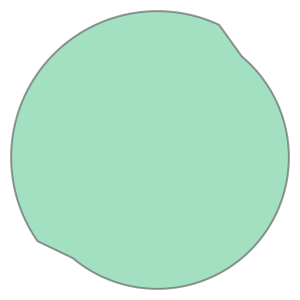

In [271]:
x,y = polygon(
        R1 = 1800,
        R2 = 2000,
        alpha = 75,
        rot_angle = 50,
        xdisplacement = 1000,
        ydisplacement = -500)

points = list(zip(x,y))
poly = Polygon(points)
poly


# Sur la caméra qui pose probème

In [80]:
ds_topo = xr.open_dataset("/home/barroisl/Transect_MC_auto/topographie/topo_params_250m.nc")
cha_thomas = xr.open_dataset("/home/barroisl/Transect_MC_auto/s2m_simu/chartreuse_thomas.nc")
ds_topo_thomas = xr.open_dataset("/home/barroisl/Transect_MC_auto/topographie/chartreuse_thomas_topo_params.nc")

def plot_1(nom_transect,xlim,ylim,cmap):

    fig, ax = plt.subplots(figsize = (9,9),layout = 'constrained')

    vmin, vmax = 500,1600

    #ds_topo.zs.plot(ax = ax, add_colorbar = True, cmap = 'viridis', vmin = vmin, vmax = vmax)
    #cha_thomas.zs.plot(ax = ax, add_colorbar = True, cmap = 'terrain', vmin = vmin, vmax = vmax)
    ds_topo_thomas.zs.plot(ax = ax, add_colorbar = True, cmap = 'terrain', vmin = vmin, vmax = vmax)
    
    file = np.loadtxt("/home/barroisl/Transect_MC_auto/camera_tgt/"+nom_transect+".txt")
    for i,l in enumerate(file) :
        ax.scatter(l[0],l[1],c = l[2], cmap = cmap, marker = 'o',vmin = vmin, vmax = vmax)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')

In [81]:
ds_topo = xr.open_dataset("/home/barroisl/Transect_MC_auto/topographie/topo_params_250m.nc")
cha_thomas = xr.open_dataset("/home/barroisl/Transect_MC_auto/s2m_simu/chartreuse_thomas.nc")
ds_topo_thomas = xr.open_dataset("/home/barroisl/Transect_MC_auto/topographie/chartreuse_thomas_topo_params.nc")

def plot_2(nom_transect,vmin,vmax):
    
    fig, ax = plt.subplots(figsize = (5,5),layout = 'constrained')

    #directory  = "/home/barroisl/Transect_MC_auto/Data/guiers_250/"
    file = np.loadtxt("/home/barroisl/Transect_MC_auto/camera_tgt/"+nom_transect+".txt")
    for i,l in enumerate(file) :
        Pos = np.array([[l[0],l[1]],[l[0],l[1]]])
        z = interpolate(
            ds = ds_topo_thomas, # cha_thomas, #ds_topo,
            points = Pos,
            var_name ='zs',
            x_dim = "x",
            y_dim = "y",
            )[0]
        ax.scatter(z,l[2],color = 'k')#, cmap = 'terrain', marker = 'o',vmin = vmin, vmax = vmax)

    ax.plot([0,2000],[0,2000],color = 'k',linestyle = 'dashed')
    ax.set_xlim((vmin,vmax))
    ax.set_ylim((vmin,vmax))

    ax.set_aspect('equal')
    ax.set_xlabel('z_interp_topo')
    ax.set_ylabel('z caméra')

    ax.spines[['left','right', 'top', 'bottom']].set_visible(False)

## Guiers 1

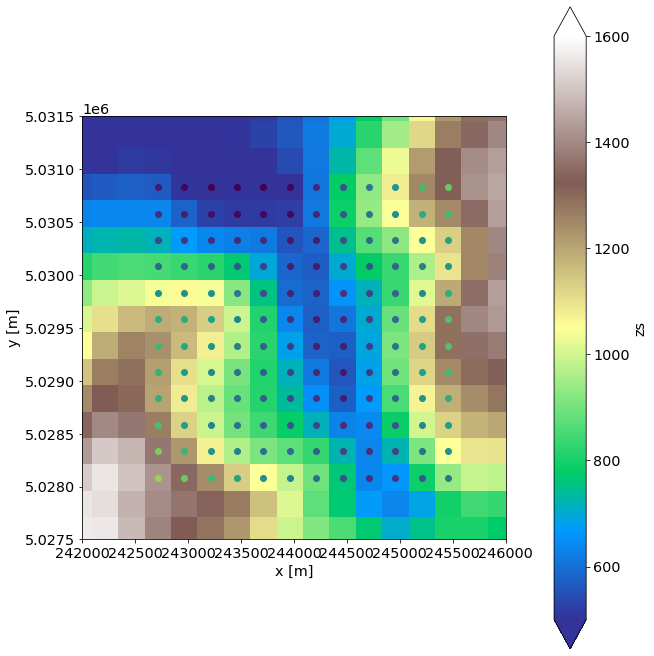

In [84]:
xlim = (242000,246000)
ylim = (5027500,5031500)
plot_1("polygon_guiers",xlim,ylim,"viridis")

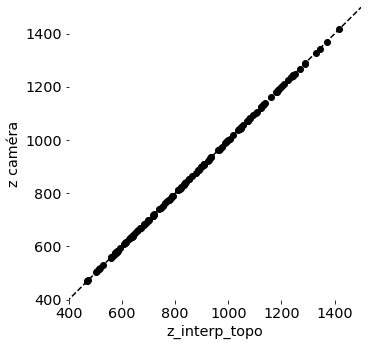

In [88]:
vmin, vmax = 400,1500
plot_2("polygon_guiers",vmin, vmax)